In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import  seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# **Day 3 — Feature Engineering & Evaluation**

## Dataset

Use the **cleaned Titanic dataset** from Day 2 (`titanic_cleaned.csv`).

**Goal:** Create new features, explore them, and understand how they relate to survival **before modeling**.

This exercise aligns with:

-   DataCamp Associate Data Scientist
    
-   PCED (feature creation, evaluation, and interpretation)
    

* * *

## Objective

-   Engineer meaningful features from existing columns.
    
-   Evaluate the usefulness of these features by analyzing their **distributions and relationship with survival**.
    
-   Practice **thinking like a model** without training an actual model yet.
    

* * *

## Exercise Instructions

### 1\. Review Existing Features

List all columns from your cleaned dataset and note which might **need transformation** or **can be combined**.

**Output:** Section titled **Existing Features Overview**

-   Include column names, data types, and any missing value considerations.
    

* * *

### 2\. Feature Engineering

Create the following new features (or any others you think are useful):

1.  **IsChild** — binary feature: 1 if Age ≤ 12, else 0
    
2.  **AgeCategory** — categorize Age into groups: Child, Teen, Adult, Senior
    
3.  **IsAlone** — binary feature: 1 if `Family_Size == 1`, else 0
    
4.  **Title** — extract from Name (Mr, Mrs, Miss, Master, etc.)
    

**Optional extras:**

-   `Fare_Per_Person`
    
-   `Has_Cabin` / `Cabin_Deck`
    
-   `Family_Size_Category`
    

**Output:** Section titled **New Features Created**

-   Describe each feature in words
    
-   Show the **distribution using `.value_counts()` or a small table**
    

* * *

### 3\. Feature Evaluation

For each new feature:

-   Analyze its **distribution** (counts or percentages)
    
-   Compare with the **target variable `Survived`**
    

Example visualizations:

-   Bar chart: `Title` vs Survival Rate
    
-   Stacked bar: `IsAlone` vs Survival
    
-   Normalized bar: `AgeCategory` vs Survival
    

**Output:** Section titled **Feature Evaluation**

-   Include at least one plot per feature
    
-   Short written insights, e.g.:
    
    -   “Children had higher survival rates”
        
    -   “Passengers traveling alone were less likely to survive”
        
    -   “Certain titles (Ms, Lady, Master) had near 100% survival”
        

* * *

### 4\. Detecting Imbalance

-   Check **class balance** in both the target and new binary features:
    
    -   Example: proportion of `IsChild == 1` vs `0`
        
    -   Proportion of `IsAlone == 1` vs `0`
        

**Output:** Section titled **Feature Imbalance Check**

-   Include table or bar chart
    
-   Note any mild or strong imbalances
    

* * *

### 5\. Key Insights from Feature Engineering

From your evaluation, answer:

-   Which features are **most informative for predicting survival**?
    
-   Are any features **highly imbalanced or rare**?
    
-   Could some features be **combined or transformed further**?
    

**Output:** Bullet list titled **Key Feature Insights**

* * *

### 6\. Exam Reflection (Theory)

Answer briefly:

1.  Why is feature engineering important before modeling?
    
2.  How do new features improve a model’s predictive ability?
    
3.  Why is it useful to visualize engineered features with the target variable?
    
4.  How can feature imbalance affect model performance?
    

**Output:** Section titled **Feature Engineering Exam Notes**

* * *

## Deliverables

-   Updated dataset with new features (`titanic_features.csv`)
    
-   Visualizations (bar charts, normalized plots, stacked bars)
    
-   Written analysis sections:
    
    -   Existing Features Overview
        
    -   New Features Created
        
    -   Feature Evaluation
        
    -   Feature Imbalance Check
        
    -   Key Feature Insights
        
    -   Feature Engineering Exam Notes

In [ ]:
import pandas as pd

titanic = pd.read_csv('/content/drive/MyDrive/30_days_of_Code/titanic_cleaned.csv')

# Display the first 5 rows of the DataFrame
print(titanic.head(3))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare    Cabin Embarked  
0      0         A/5 21171   7.2500  B96 B98        S  
1      0          PC 17599  71.2833      C85        C  
2      0  STON/O2. 3101282   7.9250  B96 B98        S  


In [ ]:
titanic["Family Size"] = titanic["SibSp"] + titanic["Parch"] + 1
titanic["IsAlone"] = (titanic["Family Size"] == 1).astype(int)
titanic["IsAlone"].value_counts()

,count
IsAlone,
1,537
0,354


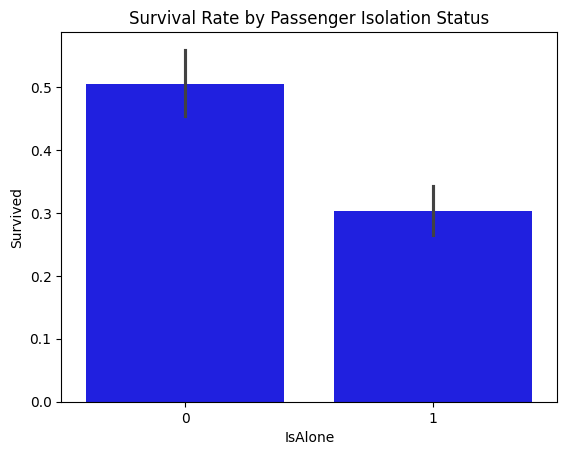

In [ ]:
sns.barplot(x="IsAlone", y="Survived", data=titanic, color="blue")
plt.title("Survival Rate by Passenger Isolation Status")
plt.show()

A 61–39 split represents a mild class imbalance, which usually does not require resampling but should be monitored during model evaluation.

In [ ]:
titanic["IsChild"] = (titanic["Age"] <= 18).astype(int)
titanic["IsChild"].value_counts()

,count
IsChild,
0,752
1,139


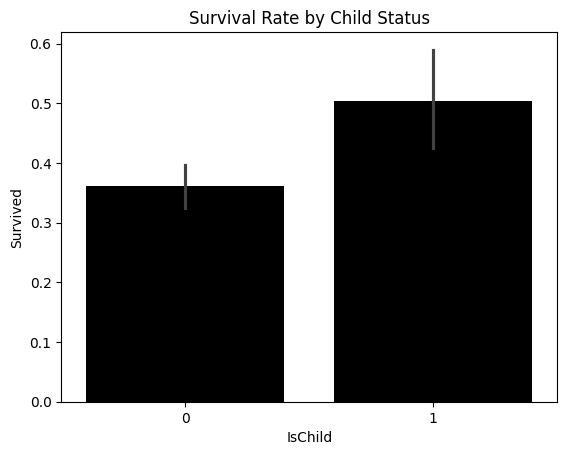

In [ ]:
sns.barplot(x="IsChild", y="Survived", data=titanic, color="black")
plt.title("Survival Rate by Child Status")
plt.show()

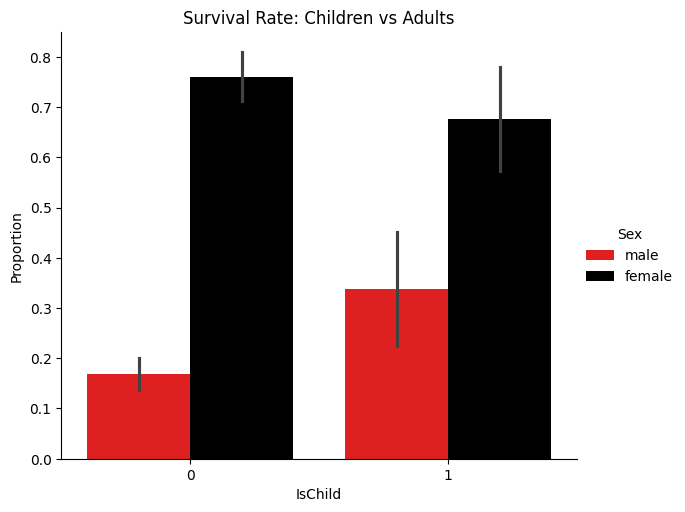

In [ ]:
sns.catplot(
    data=titanic,
    x="IsChild",
    y="Survived",
    hue="Sex",
    kind="bar",
    palette=["red", "black"],
    height=5,
    aspect=1.2
)

plt.ylabel("Proportion")
plt.title("Survival Rate: Children vs Adults")
plt.show()


In [ ]:
titanic.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
titanic["Name"].head(10)
titanic["Title"] = titanic["Name"].str.extract(r",\s*([^\.]+)\.")

# Group rare titles
titanic["Title"] = titanic["Title"].replace(
    ["Lady","Countess","Capt","Col","Don","Dr","Major",
     "Rev","Sir","Jonkheer","Dona", "the Countess"], "Rare"
)

titanic["Title"] = titanic["Title"].replace(
    {"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"}
)

# titanic["Title"].value_counts()

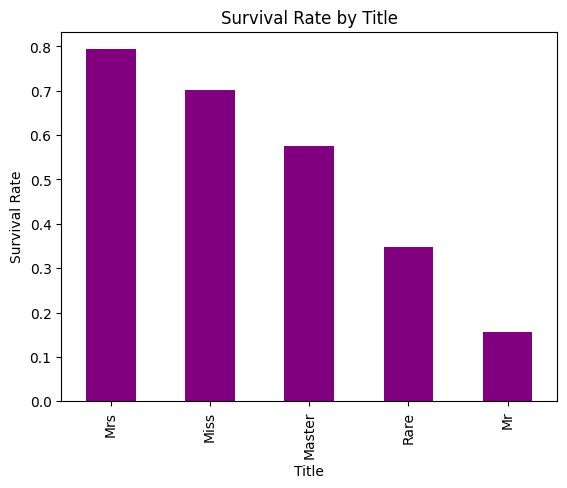

In [ ]:
title_survival = titanic.groupby('Title')['Survived'].mean().sort_values(ascending=False)
title_survival.plot(kind='bar', color='purple')
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Title")
plt.show()

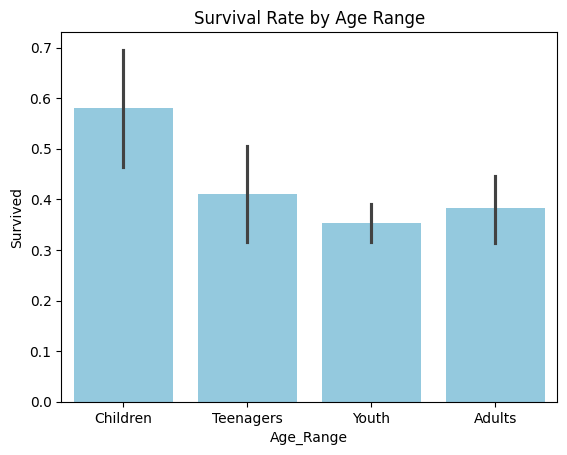

In [ ]:
titanic["Age"].value_counts().sum()

bins = [0, 12, 19, 35, 100]
categories = ["Children", "Teenagers", "Youth", "Adults"]

titanic["Age_Range"] = pd.cut(titanic["Age"], bins=bins, labels=categories, right=True)
sns.barplot(data=titanic, x= 'Age_Range', y= 'Survived', color='skyblue')
plt.title("Survival Rate by Age Range")
plt.show()

In [ ]:
titanic[:]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family Size,IsAlone,IsChild,Title,Age_Range
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S,2,0,0,Mr,Youth
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,2,0,0,Mrs,Adults
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S,1,1,0,Miss,Youth
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,2,0,0,Mrs,Youth
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S,1,1,0,Mr,Youth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,B96 B98,S,1,1,0,Rare,Youth
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,B42,S,1,1,0,Miss,Teenagers
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,B96 B98,S,4,0,0,Miss,Youth
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C148,C,1,1,0,Mr,Youth


In [ ]:
titanic.to_csv('/content/drive/MyDrive/30_days_of_Code/titanic_feature.csv', index=False)